In [ ]:
from geotiff import GeoTiff
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from geopy.distance import geodesic

In [61]:
%matplotlib inline

In [93]:
tiff_file = "assets/DGM_R25.tif"
geo_tiff = GeoTiff(tiff_file)

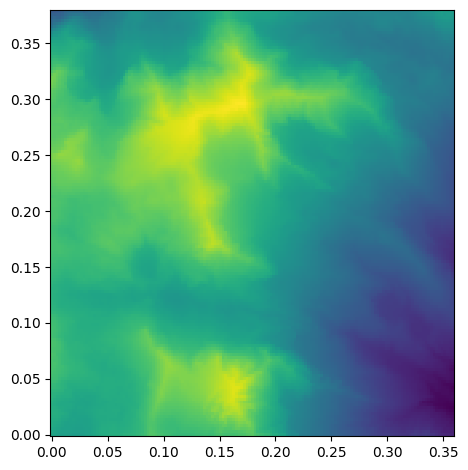

In [ ]:
def coord_arrays_to_meters(lat, lon):
    origin = (np.min(lat), np.min(lon))
    x_array = np.zeros_like(lon)
    y_array = np.zeros_like(lat)
    for i in range(lat.shape[0]):
        for j in range(lat.shape[1]):
            point = (lat[i, j], lon[i, j])
            x_array[i, j] = geodesic(origin, (origin[0], point[1])).meters
            y_array[i, j] = geodesic(origin, (point[0], origin[1])).meters
    return x_array, y_array

def generate_rectified_coord_arrays(wgs_84_box, xlen, ylen):
    """
    Generate rectified coordinate arrays for a given bounding box in WGS 84 coordinates.
    The origin of the coordinate system is set to the lower-left corner of the bounding box, and the coordinates are in meters.
    This generates regular grid. The deviation from the original coordinates is larger the further away from the origin. The deviation is smaller the smaller the bounding box is.
    Parameters:
    - wgs_84_box: A tuple containing the lower-left and upper-right corners of the bounding box in WGS 84 coordinates (latitude, longitude).
    - xlen: The number of points in the x-direction (longitude).
    - ylen: The number of points in the y-direction (latitude).
    """
    origin = wgs_84_box[0]
    max = wgs_84_box[1]
    y = np.linspace(0, geodesic(origin, (origin[0], max[1])).meters, xlen)
    #y = np.max(y)-y
    x = np.linspace(0, geodesic(origin, (max[0], origin[1])).meters, ylen)

    xarr, yarr= np.meshgrid(x, y, indexing="xy")
    return xarr, yarr

def scale(array, x_array, y_array, factor, z_scale=1):
    x_array = x_array * factor
    y_array = y_array * factor
    array = array * factor * z_scale
    return array, x_array, y_array


bbox = ((14.039583, 47.691855), (14.089708, 47.723852))
array = geo_tiff.read_box(bbox)
if array.size == 0:
    print("No data found in the specified bounding box.")
if array.size > 0:
    fig, ax = plt.subplots()#subplot_kw={"projection": "3d"})
    lon_array, lat_array = geo_tiff.get_coord_arrays(bbox)
    geowgs_84_box = ((np.min(lat_array), np.min(lon_array)), (np.max(lat_array), np.max(lon_array)))
    
    # Flipping the array. The origin is now in the bottom left corner.
    # Meaning y increases upwards and x increases to the right
    array = np.flip(array, axis=0)

    # If using:
    # geo_tiff.get_bBox_wgs_84(bbox)
    # The returned bounding box is invalid. I suppose this is a bug
    x_array, y_array = generate_rectified_coord_arrays(geowgs_84_box, lon_array.shape[0], lon_array.shape[1])
    
    array, x_array, y_array = scale(array, x_array, y_array, factor=1e-4)
    ax.pcolormesh(x_array, y_array, array, cmap="viridis")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

In [22]:
import numpy as np
from stl import mesh
%matplotlib inline

# Define the 8 vertices of the cube
vertices = np.array([\
    [-1, -1, -1],
    [+1, -1, -1],
    [+1, +1, -1],
    [-1, +1, -1],
    [-1, -1, +1],
    [+1, -1, +1],
    [+1, +1, +1],
    [-1, +1, +1]])
# Define the 12 triangles composing the cube
faces = np.array([\
    [0,3,1],
    [1,3,2],
    [0,4,7],
    [0,7,3],
    [4,5,6],
    [4,6,7],
    [5,1,2],
    [5,2,6],
    [2,3,6],
    [3,7,6],
    [0,1,5],
    [0,5,4]])

# Create the mesh
cube = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
#for i, f in enumerate(faces):
#    for j in range(3):
#        cube.vectors[i][j] = vertices[f[j],:]

figure = plt.figure()
axes = mplot3d.Axes3D(figure)

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(cube.vectors))

# Auto scale to the mesh size
scale = cube.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
cube.vectors

array([[[-1., -1., -1.],
        [-1.,  1., -1.],
        [ 1., -1., -1.]],

       [[ 1., -1., -1.],
        [-1.,  1., -1.],
        [ 1.,  1., -1.]],

       [[-1., -1., -1.],
        [-1., -1.,  1.],
        [-1.,  1.,  1.]],

       [[-1., -1., -1.],
        [-1.,  1.,  1.],
        [-1.,  1., -1.]],

       [[-1., -1.,  1.],
        [ 1., -1.,  1.],
        [ 1.,  1.,  1.]],

       [[-1., -1.,  1.],
        [ 1.,  1.,  1.],
        [-1.,  1.,  1.]],

       [[ 1., -1.,  1.],
        [ 1., -1., -1.],
        [ 1.,  1., -1.]],

       [[ 1., -1.,  1.],
        [ 1.,  1., -1.],
        [ 1.,  1.,  1.]],

       [[ 1.,  1., -1.],
        [-1.,  1., -1.],
        [ 1.,  1.,  1.]],

       [[-1.,  1., -1.],
        [-1.,  1.,  1.],
        [ 1.,  1.,  1.]],

       [[-1., -1., -1.],
        [ 1., -1., -1.],
        [ 1., -1.,  1.]],

       [[-1., -1., -1.],
        [ 1., -1.,  1.],
        [-1., -1.,  1.]]], dtype=float32)